## Prepare various glyphs to be eventually used in the dataset

### **Star** – filled, with random color of the border and fill, and random border width

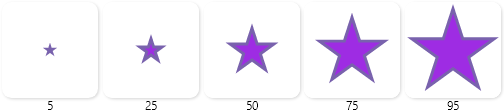

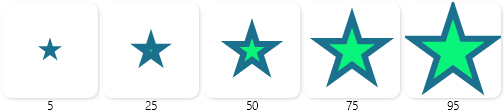

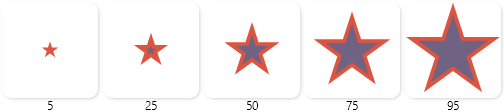

In [53]:
import mglyph as mg
import numpy as np
import random
from typing import Callable

def star(x: float, canvas: mg.Canvas, bordercolor, fillcolor, linewidth) -> None:
    canvas.tr.translate(0, mg.lerp(x, 0, 0.05))
    radius = mg.lerp(x, 0.01, canvas.ysize / 2)

    vertices = []
    for segment in range(5):
        vertices.append(mg.orbit(canvas.center, segment * 2 * np.pi / 5, radius))
        vertices.append(mg.orbit(canvas.center, (segment + 0.5) * 2 * np.pi / 5,
                         np.cos(2 * np.pi / 5) / np.cos(np.pi / 5) * radius))

    canvas.polygon(vertices, linecap='round', style='fill', color=fillcolor) 
    canvas.polygon(vertices, width=linewidth, linecap='round', style='stroke', color=bordercolor) 

def random_star() -> Callable[[float, mg.Canvas], None]:
    bordercolor = tuple(random.random() for _ in range(3))
    fillcolor = random.choice([tuple(random.random() for _ in range(3)), 'white'])
    linewidth = f'{random.uniform(0.01, 150)}p'
    return lambda x, canvas: star(x, canvas, bordercolor, fillcolor, linewidth)

for _ in range(3):
    mg.show(random_star())

### Random **textual character**

This <mark>can be improved</mark> by also randomly selecting the font name, weight, slant, etc.

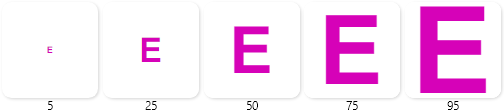

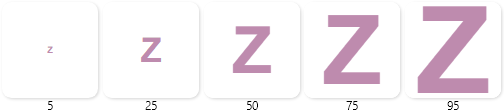

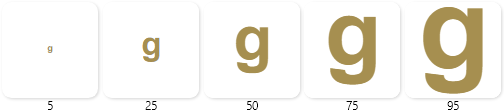

In [54]:
def scaled_letter(x: float, canvas: mg.Canvas, color, character) -> None:
    canvas.text(character, (0,0), 'Arial', mg.lerp(x, 0.05, 2.0), 
                anchor='center', color=color, font_weight='bold', font_slant='upright')

def random_letter() -> Callable[[float, mg.Canvas], None]:
    color = tuple(random.random() for _ in range(3))
    character = random.choice('abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZěščřžýáíéóúťďňĚŠČŘŽÝÁÍÉÓÚŤĎŇ0123456789')
    return lambda x, canvas: scaled_letter(x, canvas, color, character)

for _ in range(3):
    mg.show(random_letter())

## Now Make a Dataset

### First just random stars – `data/stars-small.zip` and `data/stars-large.zip`

In [56]:
import src.dataset_forming as df

# Stars - small version
with df.GlyphExporter(filepath='data/stars-small.zip', dataset_name="Stars (small)") as exporter:
    shit_to_disappear = {"version": "1.0.0", 'name': ""}
    for _ in range(10):
        exporter.add(mg.export(random_star(), path=None, short_name="star", silent=True, **shit_to_disappear,
                               xvalues=np.random.uniform(0.0, 100.0, 10)))

# Stars - large version
with df.GlyphExporter(filepath='data/stars-large.zip', dataset_name="Stars (large)") as exporter:
    shit_to_disappear = {"version": "1.0.0", 'name': ""}
    for _ in range(100):
        exporter.add(mg.export(random_star(), path=None, short_name="star", silent=True, **shit_to_disappear,
                               xvalues=np.random.uniform(0.0, 100.0, 100)))

### Then a mixture of stars and letters `data/stars-and-letters.zip`

In [59]:
import src.dataset_forming as df

with df.GlyphExporter(filepath='data/stars-and-letters.zip', dataset_name="Stars and Letters") as exporter:
    shit_to_disappear = {"version": "1.0.0", 'name': ""}
    for _ in range(10):
        exporter.add(mg.export(random_star(), path=None, short_name="star", silent=True, **shit_to_disappear,
                               xvalues=np.linspace(0.0, 100.0, 10)))
        exporter.add(mg.export(random_letter(), path=None, short_name="letter", silent=True, **shit_to_disappear,
                               xvalues=np.linspace(0.0, 100.0, 10)))
        

## Display Dataset

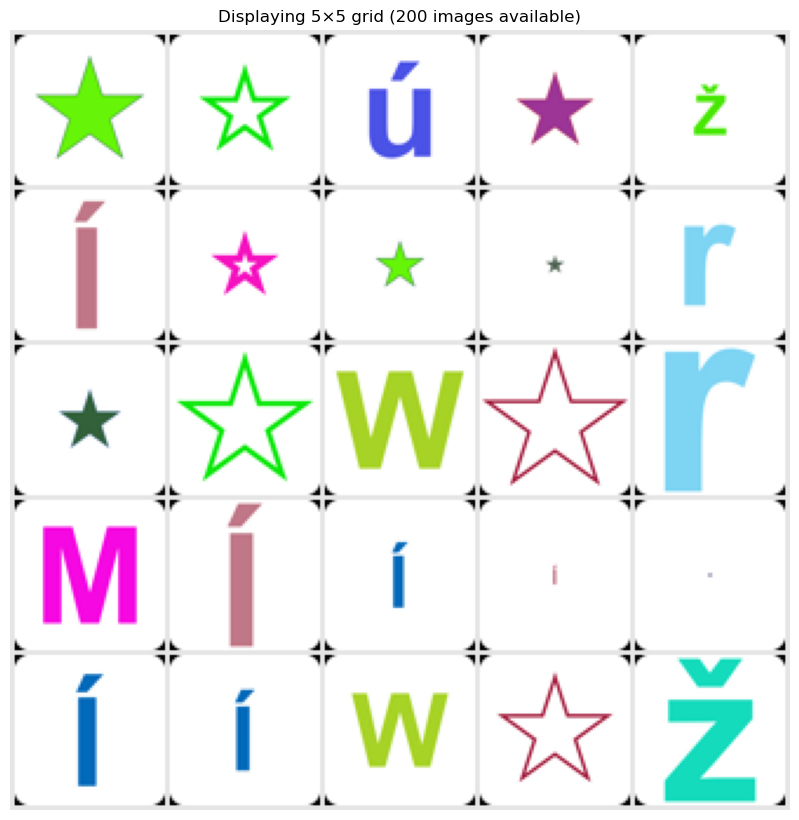

In [1]:
import src.dataset_forming as df

df.display_dataset('data/stars-and-letters.zip')